In [12]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.optim import SGD
from torch.nn import SmoothL1Loss

In [13]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
df = pd.read_csv('solarpowergeneration.csv')
data = df.to_numpy(dtype=float)
data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)
X_np = data[:, 0:20]
Y_np = data[:, 20]
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X_np)
y_scaler = StandardScaler()
Y_scaled = y_scaler.fit_transform(Y_np.reshape(-1, 1)).flatten()
X = torch.tensor(X_scaled, dtype=torch.float32).to(device)
Y = torch.tensor(Y_scaled, dtype=torch.float32).to(device)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [14]:
device

'cuda'

In [15]:
class weather_net_v1(nn.Module):
    def __init__(self, in_feature, hidden_unit):
        super().__init__()
        self.layer1 = nn.Linear(in_feature, hidden_unit)
        self.layer2 = nn.Linear(hidden_unit, 2 * hidden_unit)
        self.layer3 = nn.Linear(2 * hidden_unit, 2 * hidden_unit)
        self.layer4 = nn.Linear(2 * hidden_unit, hidden_unit)
        self.layer5 = nn.Linear(hidden_unit, 1)
        self.gelu = torch.nn.GELU()

    def forward(self, x):
        x = self.gelu(self.layer1(x))
        x = self.gelu(self.layer2(x))
        x = self.gelu(self.layer3(x))
        x = self.gelu(self.layer4(x))
        return torch.clamp(self.layer5(x), min=-5, max=5)  # Output bounded

In [16]:
model_1 = weather_net_v1(X.shape[1], 64).to(device)
loss_fn = SmoothL1Loss()
optimizer = SGD(model_1.parameters(), lr=0.001, momentum=0.9)

In [17]:
data = {}

In [18]:
for epoch in range(30):
    model_1.train()
    for i in range(len(x_train)):
        optimizer.zero_grad()
        y_pred = model_1(x_train[i])
        loss = loss_fn(y_pred, y_train[i].unsqueeze(0))
        loss.backward()
        optimizer.step()

    # Evaluation
    model_1.eval()
    loss_avg = 0
    with torch.inference_mode():
        for i in range(len(x_test)):
            y_pred = model_1(x_test[i].unsqueeze(0))
            loss_avg += loss_fn(y_pred.squeeze(), y_test[i])
    print(f"Epoch {epoch+1}, Test Loss: {loss_avg / len(x_test):.4f}")
    data[epoch+1]=loss_avg / len(x_test)

Epoch 1, Test Loss: 0.1236
Epoch 2, Test Loss: 0.1141
Epoch 3, Test Loss: 0.1111
Epoch 4, Test Loss: 0.1093
Epoch 5, Test Loss: 0.1079
Epoch 6, Test Loss: 0.1066
Epoch 7, Test Loss: 0.1055
Epoch 8, Test Loss: 0.1045
Epoch 9, Test Loss: 0.1036
Epoch 10, Test Loss: 0.1027
Epoch 11, Test Loss: 0.1019
Epoch 12, Test Loss: 0.1011
Epoch 13, Test Loss: 0.1004
Epoch 14, Test Loss: 0.0998
Epoch 15, Test Loss: 0.0992
Epoch 16, Test Loss: 0.0986
Epoch 17, Test Loss: 0.0982
Epoch 18, Test Loss: 0.0977
Epoch 19, Test Loss: 0.0973
Epoch 20, Test Loss: 0.0970
Epoch 21, Test Loss: 0.0966
Epoch 22, Test Loss: 0.0964
Epoch 23, Test Loss: 0.0961
Epoch 24, Test Loss: 0.0959
Epoch 25, Test Loss: 0.0956
Epoch 26, Test Loss: 0.0955
Epoch 27, Test Loss: 0.0953
Epoch 28, Test Loss: 0.0951
Epoch 29, Test Loss: 0.0950
Epoch 30, Test Loss: 0.0948


In [21]:
data

{1: tensor(0.1236, device='cuda:0'),
 2: tensor(0.1141, device='cuda:0'),
 3: tensor(0.1111, device='cuda:0'),
 4: tensor(0.1093, device='cuda:0'),
 5: tensor(0.1079, device='cuda:0'),
 6: tensor(0.1066, device='cuda:0'),
 7: tensor(0.1055, device='cuda:0'),
 8: tensor(0.1045, device='cuda:0'),
 9: tensor(0.1036, device='cuda:0'),
 10: tensor(0.1027, device='cuda:0'),
 11: tensor(0.1019, device='cuda:0'),
 12: tensor(0.1011, device='cuda:0'),
 13: tensor(0.1004, device='cuda:0'),
 14: tensor(0.0998, device='cuda:0'),
 15: tensor(0.0992, device='cuda:0'),
 16: tensor(0.0986, device='cuda:0'),
 17: tensor(0.0982, device='cuda:0'),
 18: tensor(0.0977, device='cuda:0'),
 19: tensor(0.0973, device='cuda:0'),
 20: tensor(0.0970, device='cuda:0'),
 21: tensor(0.0966, device='cuda:0'),
 22: tensor(0.0964, device='cuda:0'),
 23: tensor(0.0961, device='cuda:0'),
 24: tensor(0.0959, device='cuda:0'),
 25: tensor(0.0956, device='cuda:0'),
 26: tensor(0.0955, device='cuda:0'),
 27: tensor(0.0953, d

In [31]:
data[1].cpu()

tensor(0.1236)

In [35]:
X = { i:data[i].cpu().numpy() for i in data}

In [36]:
X

{1: array(0.12362156, dtype=float32),
 2: array(0.11407495, dtype=float32),
 3: array(0.11107665, dtype=float32),
 4: array(0.10926805, dtype=float32),
 5: array(0.10785636, dtype=float32),
 6: array(0.10663307, dtype=float32),
 7: array(0.10554201, dtype=float32),
 8: array(0.10452581, dtype=float32),
 9: array(0.10358085, dtype=float32),
 10: array(0.10270024, dtype=float32),
 11: array(0.10188097, dtype=float32),
 12: array(0.10111913, dtype=float32),
 13: array(0.10041411, dtype=float32),
 14: array(0.09976548, dtype=float32),
 15: array(0.09917176, dtype=float32),
 16: array(0.09863626, dtype=float32),
 17: array(0.09815214, dtype=float32),
 18: array(0.09771513, dtype=float32),
 19: array(0.09732074, dtype=float32),
 20: array(0.09696463, dtype=float32),
 21: array(0.09664468, dtype=float32),
 22: array(0.0963569, dtype=float32),
 23: array(0.09609749, dtype=float32),
 24: array(0.09586158, dtype=float32),
 25: array(0.09564658, dtype=float32),
 26: array(0.09545165, dtype=float3

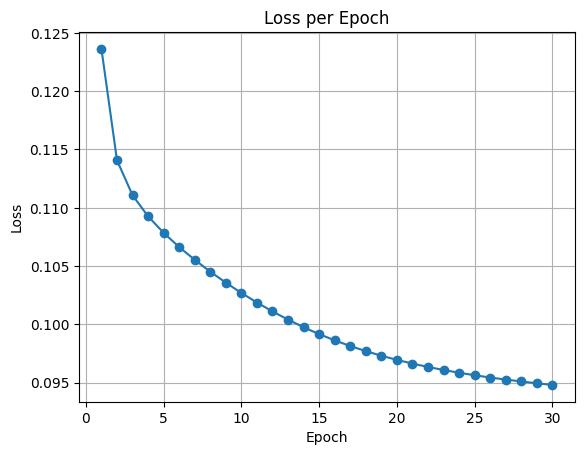

In [42]:
import matplotlib.pyplot as plt
plt.plot(list(X.keys()), list(X.values()), marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss per Epoch')
plt.grid(True)
plt.show()

In [49]:
torch.save(model_1.state_dict(),'./models/v1.pth')

In [47]:
model_1.eval()
with torch.inference_mode():
    sample_input = x_test[0].unsqueeze(0)
    normalized_output = model_1(sample_input).cpu().numpy()
    predicted_real_value = y_scaler.inverse_transform(normalized_output.reshape(-1, 1))
    print(f"Predicted Solar Power (kWh): {predicted_real_value[0][0]:.2f} and the real value is {y_scaler.inverse_transform(y_test[0].cpu().numpy().reshape(-1, 1))}")


Predicted Solar Power (kWh): 2418.24 and the real value is [[2511.2375]]
